Ejercicio 3: Agrupación o Clustering

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Configuración de estilos visuales
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

print("Entorno y librerías preparados exitosamente.")

Entorno y librerías preparados exitosamente.


In [35]:
df = pd.read_csv("https://raw.githubusercontent.com/karlaazuniga/2516662022_Zuniga_Karla/refs/heads/main/dataset/clave_H_agrupacion.csv", sep=',')


In [36]:
if df['satisfaccion'].isnull().sum() > 0:
    mediana_satisfaccion = df['satisfaccion'].median()
    df['satisfaccion'] = df['satisfaccion'].fillna(mediana_satisfaccion)
    print(f"Se detectaron nulos. Se imputó la columna 'satisfaccion' con la mediana: {mediana_satisfaccion}")

print(f"Dataset cargado correctamente desde GitHub. Dimensiones: {df.shape[0]} filas y {df.shape[1]} columnas.")
print("\nPrimeros registros cargados:")
print(df.head())

Se detectaron nulos. Se imputó la columna 'satisfaccion' con la mediana: 7.2
Dataset cargado correctamente desde GitHub. Dimensiones: 258 filas y 8 columnas.

Primeros registros cargados:
  registro_id  edad  ingresos  frecuencia_uso  gasto_promedio  satisfaccion  \
0     H-R0158    48      1292            9.60          158.47          8.45   
1     H-R0209    39       707            6.72           73.85          2.99   
2     H-R0257    37      1100            4.02           79.86          3.68   
3     H-R0037    35       582            3.25           44.88          5.18   
4     H-R0132    37      1191            6.66           55.80          7.96   

   reclamos  antiguedad_meses  
0         0                37  
1         6                 1  
2         4                 4  
3        12                 8  
4         1                23  


In [38]:
columnas_clustering = ['frecuencia_uso', 'gasto_promedio', 'satisfaccion', 'reclamos']
X = df[columnas_clustering]

print("Variables seleccionadas para el proceso de clustering:")
print(X.head())

Variables seleccionadas para el proceso de clustering:
   frecuencia_uso  gasto_promedio  satisfaccion  reclamos
0            9.60          158.47          8.45         0
1            6.72           73.85          2.99         6
2            4.02           79.86          3.68         4
3            3.25           44.88          5.18        12
4            6.66           55.80          7.96         1


In [39]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convertir a DataFrame solo para visualización de verificación
X_scaled_df = pd.DataFrame(X_scaled, columns=columnas_clustering)
print("--- DATOS NORMALIZADOS (Media ≈ 0, Desviación Estándar ≈ 1) ---")
print(X_scaled_df.head())

--- DATOS NORMALIZADOS (Media ≈ 0, Desviación Estándar ≈ 1) ---
   frecuencia_uso  gasto_promedio  satisfaccion  reclamos
0        1.378570        1.499559      0.817422 -1.218790
1        0.380390       -0.242766     -2.167405  1.775951
2       -0.555404       -0.119021     -1.790201  0.777704
3       -0.822279       -0.839258     -0.970194  4.770692
4        0.359594       -0.614416      0.549553 -0.719666


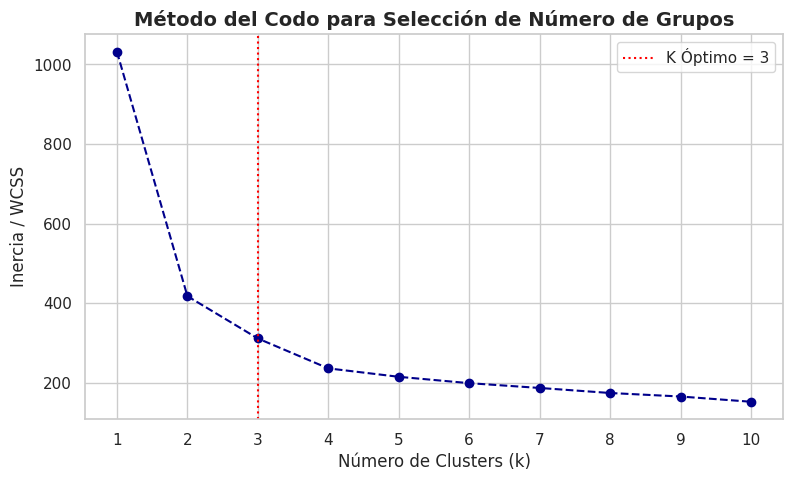

In [40]:
wcss = []
rango_clusters = range(1, 11)

for k in rango_clusters:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# Graficar el método del codo
plt.figure(figsize=(9, 5))
plt.plot(rango_clusters, wcss, marker='o', linestyle='--', color='darkblue')
plt.title('Método del Codo para Selección de Número de Grupos', fontsize=14, fontweight='bold')
plt.xlabel('Número de Clusters (k)', fontsize=12)
plt.ylabel('Inercia / WCSS', fontsize=12)
plt.xticks(rango_clusters)
plt.axvline(x=3, color='red', linestyle=':', label='K Óptimo = 3')
plt.legend()
plt.show()

In [42]:
kmeans_final = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters_asignados = kmeans_final.fit_predict(X_scaled)

# Agregar la columna del clúster asignado al DataFrame original
df['cluster'] = clusters_asignados

print("Columna 'cluster' integrada de forma exitosa al conjunto de datos original.")
print("\nDistribución de clientes por grupo encontrado:")
print(df['cluster'].value_counts())

Columna 'cluster' integrada de forma exitosa al conjunto de datos original.

Distribución de clientes por grupo encontrado:
cluster
1    122
0     70
2     66
Name: count, dtype: int64


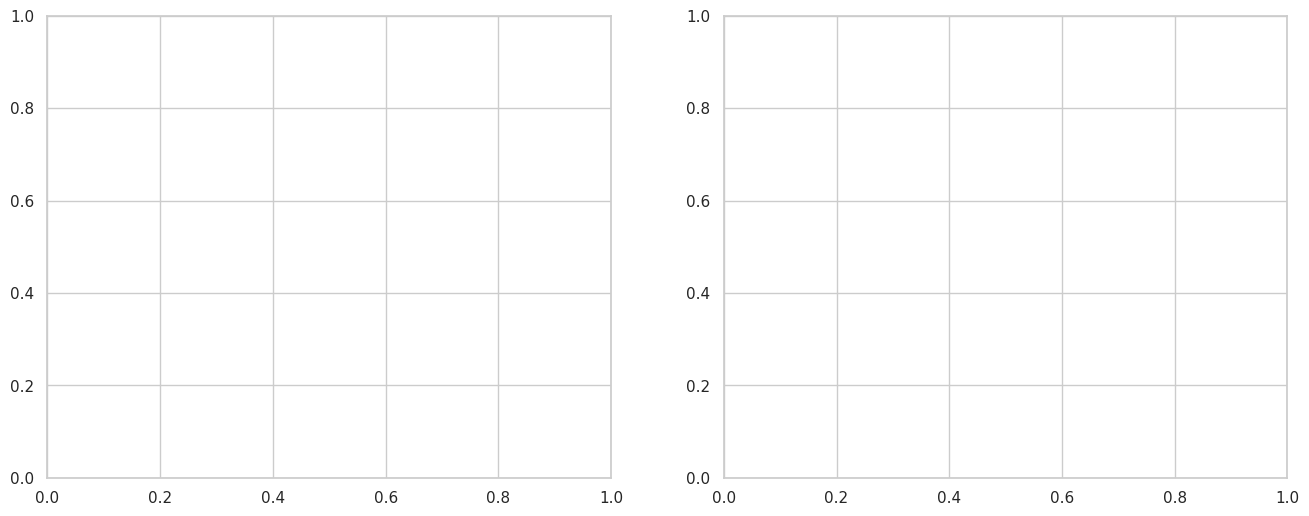

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

In [45]:
sns.scatterplot(
    data=df, x='frecuencia_uso', y='gasto_promedio',
    hue='cluster', palette='Set1', s=80, alpha=0.8, ax=axes[0]
)
axes[0].set_title('Segmentos: Frecuencia de Uso vs Gasto Promedio', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Frecuencia de Uso')
axes[0].set_ylabel('Gasto Promedio ($)')

Text(4.444444444444459, 0.5, 'Gasto Promedio ($)')

In [48]:
sns.scatterplot(
    data=df, x='reclamos', y='satisfaccion',
    hue='cluster', palette='Set1', s=80, alpha=0.8, ax=axes[1]
)
axes[1].set_title('Segmentos: Reclamos vs Satisfacción', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Cantidad de Reclamos')
axes[1].set_ylabel('Nivel de Satisfacción')

plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

In [50]:
print("\n--- VALORES PROMEDIO POR CLUSTER (PERFILAMIENTO) ---")
print(df.groupby('cluster')[columnas_clustering].mean())


--- VALORES PROMEDIO POR CLUSTER (PERFILAMIENTO) ---
         frecuencia_uso  gasto_promedio  satisfaccion  reclamos
cluster                                                        
0              6.402286       84.221286      8.031714  1.242857
1              3.313115       48.291475      5.342213  4.024590
2              9.064242      156.184848      8.793182  0.787879
